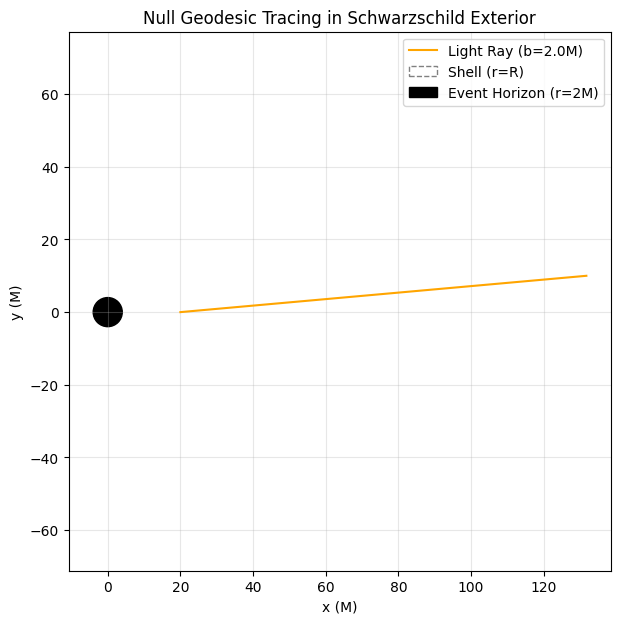

In [39]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Spacetime Parameters
M = 2.0          # Mass of the black hole
R = 1.0 * M      # Radius of the matching shell
b = 2.0 * M      # Impact parameter (b = L/E). Must be < 3*sqrt(3)*M to escape from R=3M [Gil: Variar este valor significa variar angulo de emissão]

def null_geodesic(lmbda, y):
    """
    Differential equations for a null geodesic in Schwarzschild spacetime.
    y = [t, r, phi, pr]
    """
    t, r, phi, pr = y
    
    # Event horizon cutoff to prevent coordinate singularities
    if r <= 2.001 * M:
        return [0, 0, 0, 0]
        
    # First-order equations for time, radial position, and angle
    dt_dl = 1.0 / (1.0 - 2.0 * M / r)
    dr_dl = pr
    dphi_dl = b / (r**2)
    
    # Second-order radial momentum derivative (for light)
    dpr_dl = (b**2 / r**3) - (3.0 * M * b**2 / r**4)
    
    return [dt_dl, dr_dl, dphi_dl, dpr_dl]

# 2. Initial Conditions at the shell (launching outward)
t0 = 0.0
r0 = 10*R
phi0 = 0.0       # Launch from the equator

# Calculate initial radial momentum from the null condition: E^2 = (dr/dl)^2 + V_eff
# Assuming E = 1, L = b
pr0 = np.sqrt(1.0 - (1.0 - 2.0 * M / R) * (b**2 / R**2))

y0 = [t0, r0, phi0, pr0]
lmbda_span = (0, 50)  # Range for the affine parameter

# 3. Solve the ODE system
solution = solve_ivp(
    null_geodesic, 
    lmbda_span, 
    y0, 
    method='RK45', 
    rtol=1e-8, 
    atol=1e-8,
    dense_output=True
)

# 4. Plotting the trajectory in the equatorial plane
r_vals = solution.y[1]
phi_vals = solution.y[2]


# Convert polar to Cartesian for plotting
x = r_vals * np.cos(phi_vals)
y_cart = r_vals * np.sin(phi_vals)

plt.figure(figsize=(7, 7))
plt.plot(x, y_cart, color='orange', label=f'Light Ray (b={b/M}M)')

# Draw the boundaries
shell = plt.Circle((0,0), R, color='gray', fill=False, linestyle='--', label='Shell (r=R)')
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon (r=2M)')
plt.gca().add_patch(shell)
plt.gca().add_patch(horizon)

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Null Geodesic Tracing in Schwarzschild Exterior')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# print(solution)
# print(phi_vals)
# print(r_vals)
print(len(solution.y))
print(len(solution.y[0]))

4
32


For this values of b=11.212121212121213M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=11.363636363636363M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=11.515151515151516M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=11.666666666666668M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=11.818181818181818M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=11.96969696969697M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=12.121212121212121M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=12.272727272727273M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=12.424242424242424M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=12.575757575757576M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this values of b=12.727272727272728M for Lamp 1 (East) (Ray cross the shell: r=10.0M)
For this va

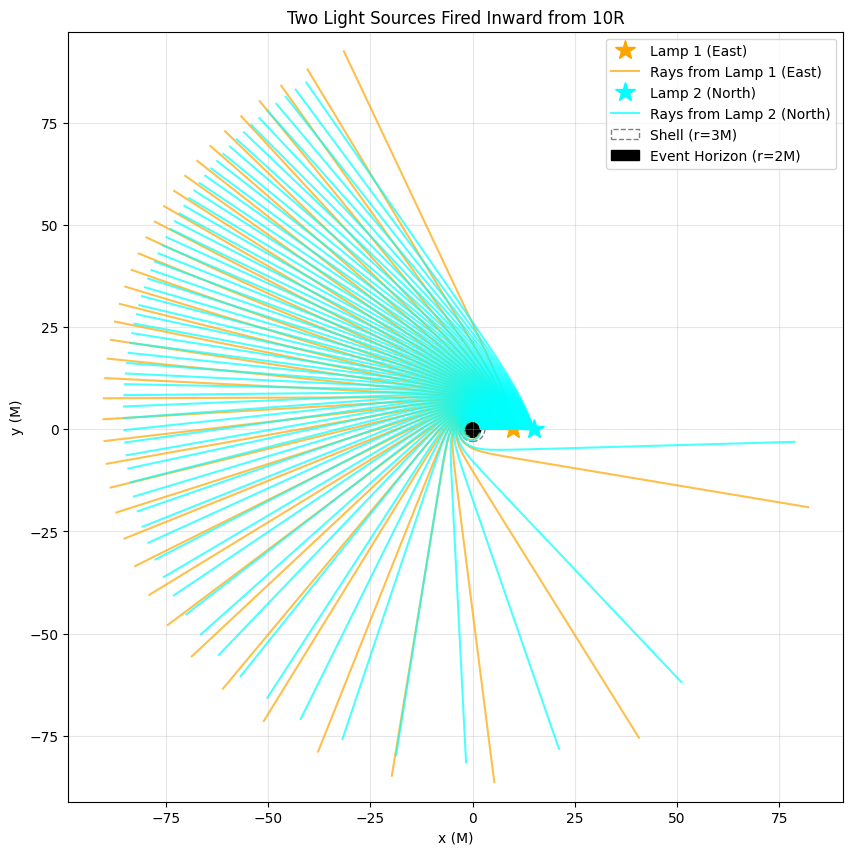

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Spacetime Parameters
M = 1.0          
R = 3.0 * M      

def null_geodesic(lmbda, y, b):
    t, r, phi, pr = y
    
    if r <= 2.001 * M:
        return [0, 0, 0, 0]
        
    dt_dl = 1.0 / (1.0 - 2.0 * M / r)
    dr_dl = pr
    dphi_dl = b / (r**2)
    dpr_dl = (b**2 / r**3) - (3.0 * M * b**2 / r**4)
    
    return [dt_dl, dr_dl, dphi_dl, dpr_dl]

def hit_horizon(lmbda, y, b):
    return y[1] - 2.001 * M
hit_horizon.terminal = True

# 2. Setup Plot
plt.figure(figsize=(10, 10))
b_values = b_values = np.linspace(0, 15, 100)*M
lmbda_span = (0, 100)  
eval_points = np.linspace(0, 100, 1000) 

# 3. Define our Light Sources procedurally: (r0, phi0, color, label)
sources = [
    (10.0 * M, 0.0, 'orange', 'Lamp 1 (East)'),
    (15.0 * M, 0.0, 'cyan', 'Lamp 2 (North)')
]

# 4. Main Simulation Loop
for r0, phi0, color, label in sources:
    
    # Plot the lamp itself
    x0 = r0 * np.cos(phi0)
    y0 = r0 * np.sin(phi0)
    plt.plot(x0, y0, '*', color=color, markersize=15, label=label)
    
    # Fire all the rays for this specific lamp
    for b in b_values:
        V_eff = (1.0 - 2.0 * M / r0) * (b**2 / r0**2)
        
        # --- NEW SAFETY CHECK ---
        if V_eff > 1.0:
            print(f"For this values of b={b/M}M for {label} (Ray cross the shell: r={r0/M}M)")
            continue
        # ------------------------
        
        pr0 = -np.sqrt(1.0 - V_eff) # Negative for inward facing
        
        # Notice we inject the lamp's specific phi0 here
        y0 = [0.0, r0, phi0, pr0]
        
        solution = solve_ivp(
            null_geodesic, lmbda_span, y0, args=(b,),
            method='RK45', t_eval=eval_points, events=hit_horizon,
            rtol=1e-8, atol=1e-8
        )
        
        r_vals = solution.y[1]
        phi_vals = solution.y[2]
        
        x = r_vals * np.cos(phi_vals)
        y_cart = r_vals * np.sin(phi_vals)
        
        # Only label the first VALID ray so the legend isn't cluttered
        ray_label = f"Rays from {label}" if 'ray_label_added' not in locals() else None
        plt.plot(x, y_cart, color=color, alpha=0.7, label=ray_label)
        locals()['ray_label_added'] = True # Quick hack to only print legend once per lamp
        
    # Reset legend tracker for the next lamp
    if 'ray_label_added' in locals():
        del locals()['ray_label_added']

# 5. Draw the environment
shell = plt.Circle((0,0), R, color='gray', fill=False, linestyle='--', label='Shell (r=3M)')
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon (r=2M)')
plt.gca().add_patch(shell)
plt.gca().add_patch(horizon)

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Two Light Sources Fired Inward from 10R')
plt.legend(loc='upper right')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

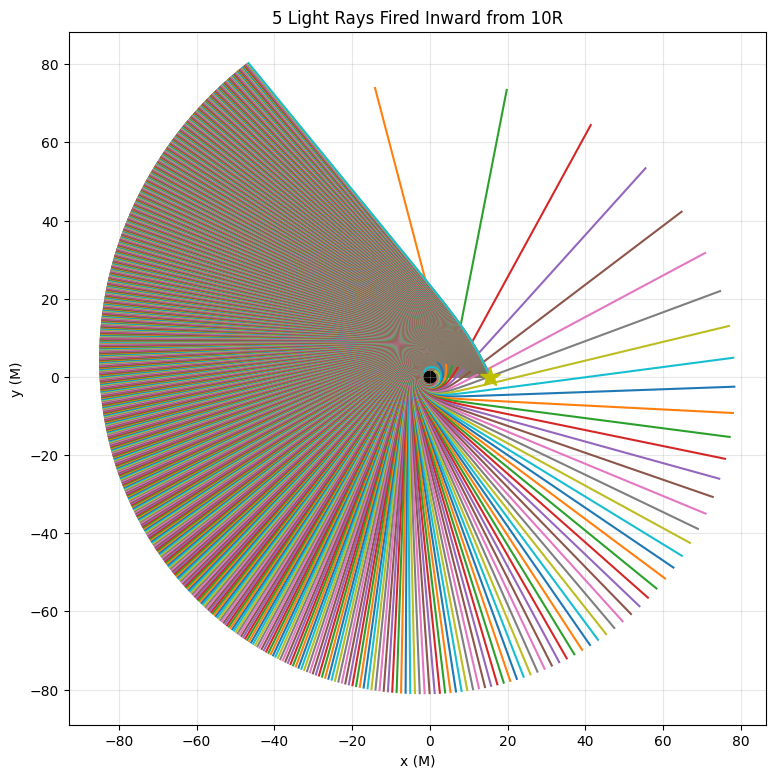

In [ ]:
# 1. Spacetime Parameters
M = 1         
R = 3.1 * M      
r0 = 5 * R    # Lamp is now positioned at 30M

def null_geodesic(lmbda, y, b):
    """
    Differential equations for a null geodesic, now accepting 'b' as an argument.
    """
    t, r, phi, pr = y
    
    # Event horizon cutoff fallback
    if r <= 2.001 * M:
        return [0, 0, 0, 0]
        
    dt_dl = 1.0 / (1.0 - 2.0 * M / r)
    dr_dl = pr
    dphi_dl = b / (r**2)
    dpr_dl = (b**2 / r**3) - (3.0 * M * b**2 / r**4)
    
    return [dt_dl, dr_dl, dphi_dl, dpr_dl]

# Stop the solver if the ray crosses the event horizon
def hit_horizon(lmbda, y, b):
    return y[1] - 2.001 * M
hit_horizon.terminal = True

# 2. Set up the plot and the array of impact parameters
plt.figure(figsize=(9, 9))

# 5 different impact parameters (negative values shoot "down", positive "up")
# b_values = [-15.0 * M, -5.0 * M, 0.0, 5.0 * M, 15.0 * M]
b_values = np.linspace(0, 15, 15)*M

lmbda_span = (0, 100)  # Increased span since rays travel from further away
eval_points = np.linspace(0, 100, 1000) # Force 1000 points for smooth plotting

# 3. Loop through each ray
for b in b_values:
    
    # Calculate the effective potential
    V_eff = (1.0 - 2.0 * M / r0) * (b**2 / r0**2)
    
    # Negative sign to shoot rays INWARD toward the black hole
    pr0 = -np.sqrt(1.0 - V_eff)
    
    y0 = [0.0, r0, 0.0, pr0]
    
    # Solve ODE, passing 'b' through the args parameter
    solution = solve_ivp(
        null_geodesic, 
        lmbda_span, 
        y0, 
        args=(b,),
        method='RK45', 
        t_eval=eval_points, 
        events=hit_horizon,
        rtol=1e-8, 
        atol=1e-8
    )
    
    # Extract and convert to Cartesian
    r_vals = solution.y[1]
    phi_vals = solution.y[2]
    
    x = r_vals * np.cos(phi_vals)
    y_cart = r_vals * np.sin(phi_vals)
    
    # Plot this specific ray
    plt.plot(x, y_cart, label=f'Ray (b = {b/M}M)')

# 4. Draw the environment
shell = plt.Circle((0,0), R, color='gray', fill=False, linestyle='--', label='Shell (r=3M)')
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon (r=2M)')
plt.gca().add_patch(shell)
plt.gca().add_patch(horizon)

# Plot the light source itself
plt.plot(r0, 0, 'y*', markersize=15, label='Lamp (r=30M)')

# Finalize formatting
plt.xlabel('x (M)')
plt.ylabel('y (M)')
# plt.title('5 Light Rays Fired Inward from 10R')
# plt.legend(loc='upper right', size)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
print(b_values)

[0.]
